# TorchPenny Doc002: Features and Ansatz

In this example, we will see how the example that how we integrate the `QLayer` into normal PyTorch module.
We will make a simple example `QLayer` class using several predefined `QSublayer` classes and put it into the PyTorch module and train it.

- **Feature**: Features encode the classic data into quantum circuit.
- **Ansatz**: Ansatz has their own parameters and trainable.

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "torchpenny" / "module.py").is_file()
)
sys.path.insert(0, str(project_root))

In [2]:
import torch
import pennylane as qml

from torchpenny.module import QLayer, QSubLayer
from torchpenny.lib.ansatz import TwoLocalAnsatz
from torchpenny.lib.features import ZZfeatureMap

## QLayer with QSubLayer

In [3]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)

        # Internal layer 
        self.zzf_input = ZZfeatureMap(self.wires, param_received=True)
        self.two_local1 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "linear")
        self.two_local2 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "circular", except_initial=True)

    def inner_gates(self, x):
        self.zzf_input(x, wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local1(wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local2(wires=range(self.wires))
        
    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]

In [4]:
qlayer = QuantumLayer(
    wires= 8, 
    q_device = "default.qubit", 
    qnode_kwargs={"diff_method": "backprop"}
    )

In [5]:
qlayer

QuantumLayer[Qnode, wires=8](
  (zzf_input): ZZfeatureMap[15]()
  (two_local1): TwoLocalAnsatz()
  (two_local2): TwoLocalAnsatz()
)

In [6]:
qlayer.input_features

{'zzf_input': torch.Size([15])}

In [7]:
data_i = qlayer.zzf_input.num_params
data_shape = (4, data_i)
data = torch.rand(data_shape) # Batched data

In [8]:
result = qlayer(data)

In [9]:
result

tensor([[ 0.0594,  0.6238,  0.4197,  0.1340,  0.1770,  0.3608,  0.3777,  0.1699],
        [ 0.0895,  0.3449,  0.2015,  0.3060,  0.1674,  0.2491,  0.0179,  0.1848],
        [ 0.1654,  0.3559,  0.4259,  0.1024,  0.1707,  0.3081, -0.0031,  0.2299],
        [ 0.0909,  0.4728,  0.4589,  0.1793,  0.0881,  0.1388,  0.1453,  0.0959]],
       dtype=torch.float64, grad_fn=<ViewBackward0>)

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

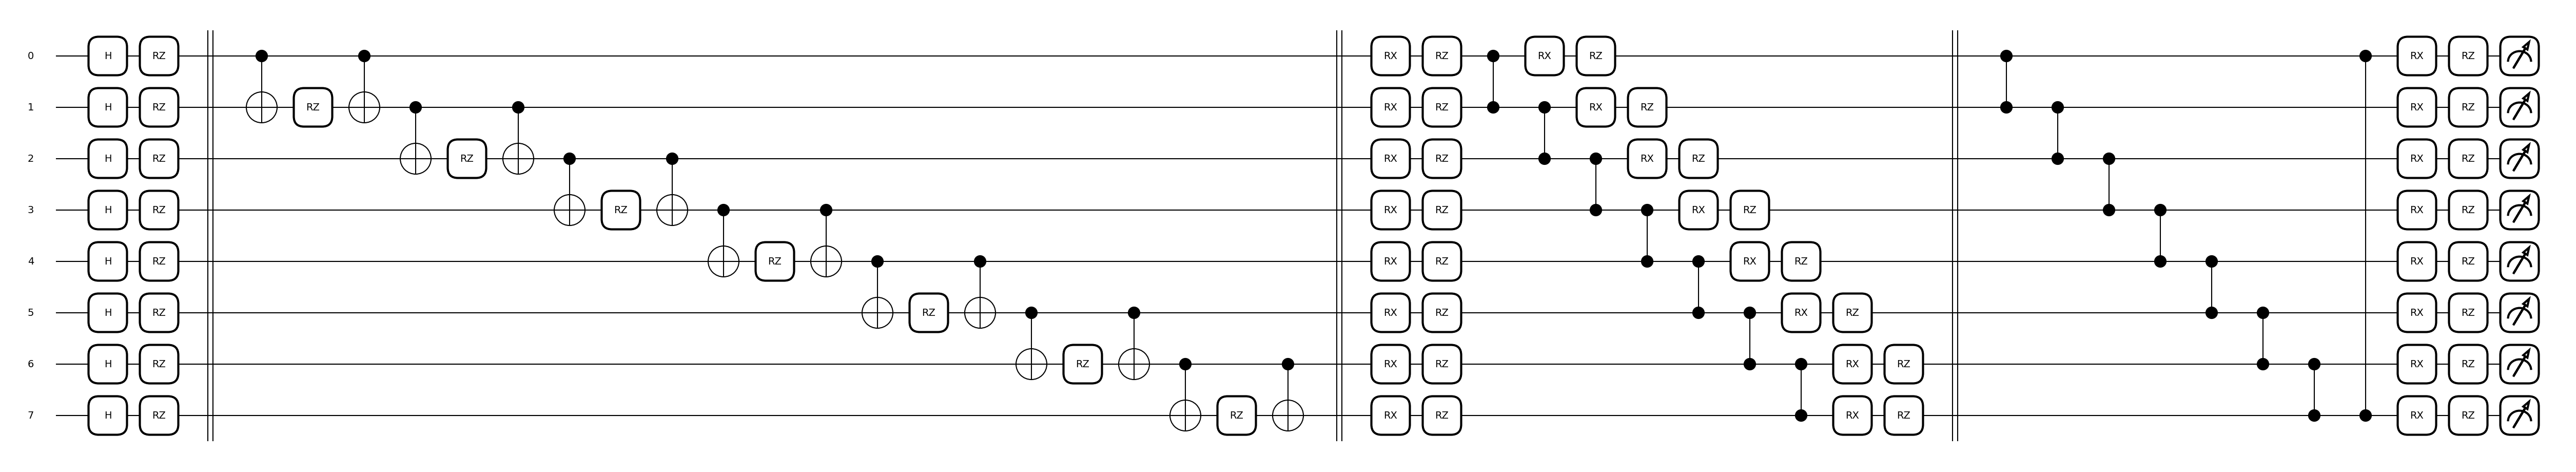

In [10]:
qml.draw_mpl(qlayer.qnode)(data)

## Torch integration

In [ ]:
from torch import nn
from torch.optim import Adam
from torch.nn import Module
torch.set_default_dtype(torch.float64)
from matplotlib import pyplot as plt

In [12]:
class ExampleModule(Module):
    def __init__(self):
        super(ExampleModule, self).__init__()
        
        qlayer = QuantumLayer(wires=8, q_device = "default.qubit", qnode_kwargs={"diff_method": "backprop"})
        _, qlayer_input_dim = qlayer.zzf_input.input_dim
        self.layers = nn.Sequential(
            nn.Linear(30, 40), nn.Tanh(),
            nn.Linear(40, qlayer_input_dim), nn.Tanh(),
            qlayer,
            nn.Linear(8, 10)
        )
    def forward(self, x):
        return self.layers(x)

In [13]:
em = ExampleModule()

In [ ]:
data = torch.rand((10, 30)) # Random input data
rand_result = torch.rand((10, 10))
initial_result = em(data) # Initial output from the model

Text(0.5, 1.0, 'Initial Output from Model')

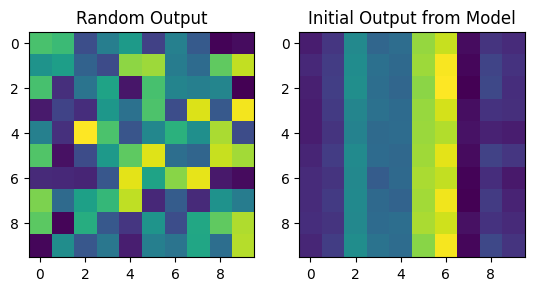

In [24]:
fig, axes= plt.subplots(1,2)
axes[0].imshow(rand_result)
axes[1].imshow(initial_result.detach().numpy())

axes[0].set_title("Random Output")
axes[1].set_title("Initial Output from Model")

In [25]:
loss_func = nn.MSELoss()

In [26]:
optim = Adam(em.parameters(), lr=0.001)

In [ ]:
# Training loop
his = []
total_epoches = 1000
for i in range(total_epoches):
    optim.zero_grad()
    loss = loss_func(em(data), rand_result)
    his.append(loss.item())
    print(f"Epoch:{i:4}/{total_epoches} \t", loss.item())
    loss.backward()
    optim.step()


Epoch:   0/1000 	 0.4561483865318651
Epoch:   1/1000 	 0.44097665200155495
Epoch:   2/1000 	 0.4261855408911757
Epoch:   3/1000 	 0.41179389709322606
Epoch:   4/1000 	 0.39782054924208127
Epoch:   5/1000 	 0.3842867637575793
Epoch:   6/1000 	 0.3712103584529963
Epoch:   7/1000 	 0.35860354478471607
Epoch:   8/1000 	 0.3464730128144454
Epoch:   9/1000 	 0.33482005599112613
Epoch:  10/1000 	 0.3236401074546087
Epoch:  11/1000 	 0.31292239735591465
Epoch:  12/1000 	 0.302651191730532
Epoch:  13/1000 	 0.29280842323114986
Epoch:  14/1000 	 0.28337615830082336
Epoch:  15/1000 	 0.2743381277538408
Epoch:  16/1000 	 0.26568021781022927
Epoch:  17/1000 	 0.2573901233946152
Epoch:  18/1000 	 0.24945666851932993
Epoch:  19/1000 	 0.24186936877904178
Epoch:  20/1000 	 0.23461831859037943
Epoch:  21/1000 	 0.2276939802621839
Epoch:  22/1000 	 0.22108666227207144
Epoch:  23/1000 	 0.21478586647986814
Epoch:  24/1000 	 0.20877974167273955
Epoch:  25/1000 	 0.20305478426997056
Epoch:  26/1000 	 0.197

Text(0, 0.5, 'Loss')

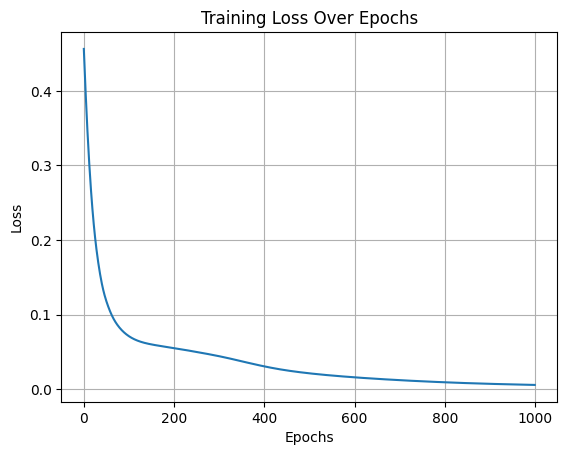

In [27]:
fig, ax= plt.subplots(1,1)
ax.plot(his)
ax.grid()
ax.set_title("Training Loss Over Epochs")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")

Text(0.5, 1.0, 'Trained Output from Model')

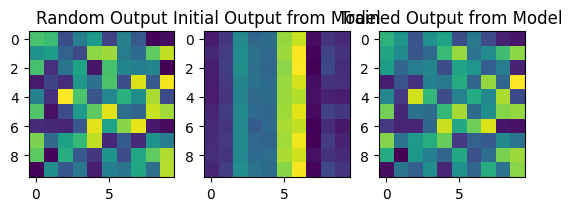

In [28]:
fig, axes= plt.subplots(1,3)
axes[0].imshow(rand_result)
axes[1].imshow(initial_result.detach().numpy())
axes[2].imshow(em(data).detach().numpy())


axes[0].set_title("Random Output")
axes[1].set_title("Initial Output from Model")
axes[2].set_title("Trained Output from Model")

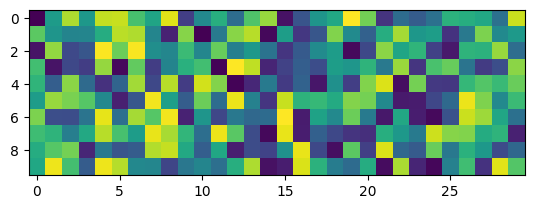

In [21]:
plt.imshow(data)